In [1]:
from itertools import chain
from rdkit.Chem import CanonSmiles
import pandas as pd

# data loading
train_df = pd.read_csv("../data/aqsoldbc.csv")
train_df["SMILES"] = train_df["SMILES"].map(CanonSmiles)
# remove overlap with test sets
biogen_df = pd.read_csv("../data/biogen.csv")
biogen_df["SMILES"] = biogen_df["SMILES"].map(CanonSmiles)
ochem_df = pd.read_csv("../data/ochem.csv")
ochem_df["SMILES"] = ochem_df["SMILES"].map(CanonSmiles)
# remove overlap for demos as well
ancenes_df = pd.read_csv("../data/ancenes.csv")
ancenes_df["SMILES"] = ancenes_df["SMILES"].map(CanonSmiles)
fatty_acids_df = pd.read_csv("../data/ralston_hoerr_joc_1942.csv")
fatty_acids_df["SMILES"] = fatty_acids_df["SMILES"].map(CanonSmiles)

test_smiles = set(chain(biogen_df["SMILES"], ochem_df["SMILES"], ancenes_df["SMILES"], fatty_acids_df["SMILES"]))
train_df = train_df[~train_df["SMILES"].isin(test_smiles)].reset_index(drop=True)

train_df.to_csv("../data/aqsoldbc_no_overlap.csv", index=False)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.manifold import TSNE, trustworthiness

In [11]:
def get_fps(smiles_list):
    """Generate Morgan Fingerprints from a list of SMILES."""
    fps = []
    valid_idx = []
    fpgen = Chem.rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2_048)
    for i, sm in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(sm)
        if mol:
            fp = fpgen.GetFingerprint(mol)
            fps.append(fp)
            valid_idx.append(i)
        else:
            print(f"Warning: Could not parse SMILES at index {i}: {sm}")
    return fps, valid_idx

In [12]:
# 1. Generate Fingerprints
train_fps, _ = get_fps(train_df['SMILES'])
ochem_fps, _ = get_fps(ochem_df['SMILES'])
biogen_fps, _ = get_fps(biogen_df['SMILES'])

In [13]:
# 2. Sheridan's Top-5 Mean Tanimoto Similarity
def get_top5_mean_tanimoto(test_fps, train_fps):
    mean_sims = []
    for tfp in test_fps:
        sims = DataStructs.BulkTanimotoSimilarity(tfp, train_fps)
        top5 = sorted(sims, reverse=True)[:5]
        mean_sims.append(np.mean(top5))
    return mean_sims

In [14]:
ochem_sims = get_top5_mean_tanimoto(ochem_fps, train_fps)
biogen_sims = get_top5_mean_tanimoto(biogen_fps, train_fps)

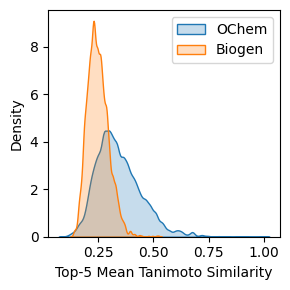

In [31]:
# Plot 1: Sheridan Similarity Distribution
plt.figure(figsize=(3, 3))
sns.kdeplot(ochem_sims, label='OChem', fill=True, bw_adjust=0.5)
sns.kdeplot(biogen_sims, label='Biogen', fill=True, bw_adjust=0.5)
plt.xlabel('Top-5 Mean Tanimoto Similarity')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig("../results/sheridan_similarity_distribution.pdf", dpi=300)
plt.show()

In [17]:
# 3. t-SNE with Neighborhood Preservation
# Combine all datasets for projection
all_smiles = train_df['SMILES'].tolist() + ochem_df['SMILES'].tolist() + biogen_df['SMILES'].tolist()
labels = ['Train']*len(train_df) + ['Ochem']*len(ochem_df) + ['Biogen']*len(biogen_df)

all_fps, valid_idx = get_fps(all_smiles)
X = np.array([list(fp) for fp in all_fps])

# Filter labels in case some SMILES were invalid
valid_labels = [labels[i] for i in valid_idx]

# Grid search for the best perplexity
perplexities = [5, 10, 20, 30, 40, 50]
best_trust = -1
best_perp = 5
best_X_tsne = None

print("Optimizing t-SNE perplexity...")
for p in perplexities:
    # Perplexity must be less than the number of samples
    if p >= len(X):
        continue
    try:
        tsne = TSNE(n_components=2, perplexity=p, random_state=42, init='pca', learning_rate='auto')
        X_tsne = tsne.fit_transform(X)
        
        # Calculate trustworthiness (k=5 neighbors is standard for local structure)
        trust = trustworthiness(X, X_tsne, n_neighbors=5)
        print(f"Perplexity: {p} | Trustworthiness: {trust:.4f}")
        
        if trust > best_trust:
            best_trust = trust
            best_perp = p
            best_X_tsne = X_tsne
    except Exception as e:
        print(f"Failed for perplexity {p}: {e}")

Optimizing t-SNE perplexity...
Perplexity: 5 | Trustworthiness: 0.9132
Perplexity: 10 | Trustworthiness: 0.9140
Perplexity: 20 | Trustworthiness: 0.9107
Perplexity: 30 | Trustworthiness: 0.9079
Perplexity: 40 | Trustworthiness: 0.9060
Perplexity: 50 | Trustworthiness: 0.9001


Optimal Perplexity: 10 (Trustworthiness: 0.914)


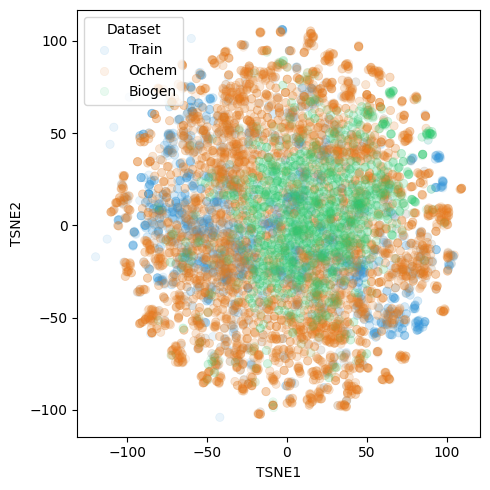

In [40]:
# Plot 2: Best t-SNE Projection
plt.figure(figsize=(5, 5))
df_tsne = pd.DataFrame({
    'TSNE1': best_X_tsne[:, 0], 
    'TSNE2': best_X_tsne[:, 1], 
    'Dataset': valid_labels
})

sns.scatterplot(
    data=df_tsne, x='TSNE1', y='TSNE2', hue='Dataset', 
    palette={'Train': '#3498db', 'Ochem': '#e67e22', 'Biogen': '#2ecc71'}, 
    alpha=0.1, edgecolor=None
)
print(f'Optimal Perplexity: {best_perp} (Trustworthiness: {best_trust:.3f})')
plt.tight_layout()
plt.savefig("../results/tsne_projection.pdf", dpi=300)
plt.show()